# Task 2 - ML pipline

Exploratory analysis of the dataset and the model used in a cv part of the task.

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Денис\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2


In [12]:
# Explore dataset directory structure
import os

dataset_path = path  # Use the path from the previous cell
print("Root directory:", dataset_path)
print("Subdirectories (classes):", os.listdir(dataset_path))

Root directory: C:\Users\Денис\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2
Subdirectories (classes): ['raw-img', 'translate.py']


In [13]:
dataset_path = path + "\\raw-img"

In [14]:
# Count images per class
from collections import Counter

class_counts = {}
for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = num_images

print("Images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Images per class:
cane: 4863
cavallo: 2623
elefante: 1446
farfalla: 2112
gallina: 3098
gatto: 1668
mucca: 1866
pecora: 1820
ragno: 4821
scoiattolo: 1862


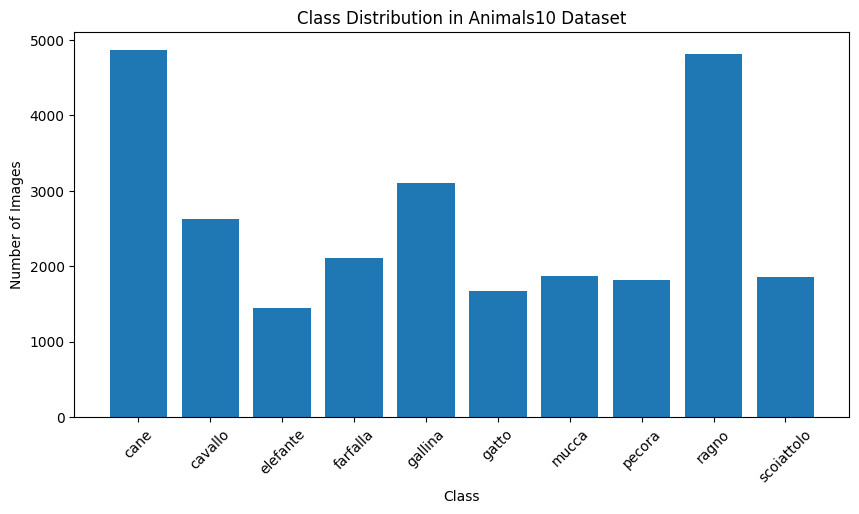

In [15]:
# Visualize class distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution in Animals10 Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

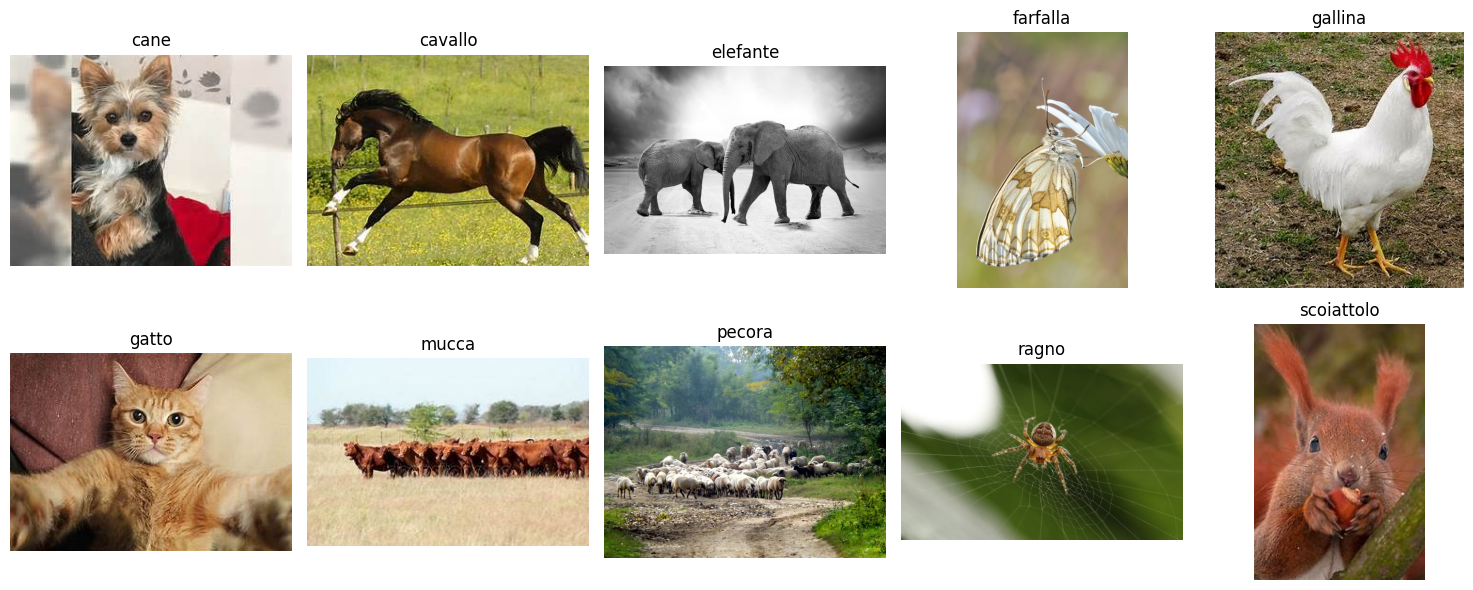

In [16]:
# Show sample images from each class
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, class_name in enumerate(list(class_counts.keys())[:10]):
    class_dir = os.path.join(dataset_path, class_name)
    sample_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if sample_images:
        img_path = os.path.join(class_dir, sample_images[0])
        img = mpimg.imread(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(class_name)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [17]:
from torchvision import models
model = models.resnet18(pretrained=True)
model

c:\Users\Денис\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Денис\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
print(len(list(model.children())))
print(list(model.children())[-1])

10
Linear(in_features=512, out_features=1000, bias=True)
